<a href="https://www.kaggle.com/code/zikriazzuri/zomato-india-features-ratings-analysis?scriptVersionId=356279012" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zikriazzuri/zomato/Zomato Restaurant Dataset.csv


**Pertanyaan Bisnis**: pemilik restoran ingin menaikan rating restorannya, apakah dengan adanya fitur has delivery online dan has table booking rating nya tinggi?

In [2]:
df = pd.read_csv('/kaggle/input/datasets/zikriazzuri/zomato/Zomato Restaurant Dataset.csv')

print(df.shape)
print(df.info())
print(df.describe())

(9551, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to 

In [3]:
print(df['Has Table booking'].value_counts())
print(df['Has Online delivery'].value_counts())

Has Table booking
No     8393
Yes    1158
Name: count, dtype: int64
Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64


- Setelah dicek menggunakan value counts, ternyata perbandingannya yang memiliki fitur dan tidak cukup timpang.

In [4]:
ar = df['Aggregate rating'] == 0
ar.sum()

pd.crosstab(ar, df['Rating text'])

Rating text,Average,Excellent,Good,Not rated,Poor,Very Good
Aggregate rating,,,,,,
False,3737,301,2100,0,186,1079
True,0,0,0,2148,0,0


In [5]:
df_rated = df[df['Aggregate rating'] > 0]

res_tb = df_rated.groupby('Has Table booking').agg({
    'Aggregate rating': ['median', 'mean', 'count']
})

res_od = df_rated.groupby('Has Online delivery').agg({
    'Aggregate rating': ['median', 'mean', 'count']
})
 
# print(result_pr)
print(res_tb)
print(res_od)


                  Aggregate rating                
                            median      mean count
Has Table booking                                 
No                             3.4  3.413970  6292
Yes                            3.6  3.587579  1111
                    Aggregate rating                
                              median      mean count
Has Online delivery                                 
No                               3.4  3.467433  5048
Yes                              3.4  3.381274  2355


- Membuat filter rating yang memiliki rating lebih dari 0, hasilnya yang tidak memiliki fitur lebih banyak dibanding yang memiliki fitur.

In [6]:
df_rated.groupby(['Price range', 'Has Table booking']).agg({
    'Aggregate rating': ['mean', 'count']
})

Aggregate rating      
                                          mean count
Price range Has Table booking                       
1           No                        3.238717  2743
            Yes                       3.700000     1
2           No                        3.377800  2491
            Yes                       3.370000   220
3           No                        3.911883   749
            Yes                       3.615705   624
4           No                        4.054369   309
            Yes                       3.701128   266

- Melakukan pemeriksaan bedasarkan price range dan has table boooking dibandingkan dengan rating, harga restoran yang murah (1) hanya memiliki 1 restoran yang memiliki fitur booking sehingga tidak relevan, dan kebanyakan restoran tidak memiliki fitur table booking serta rating juga tidak terlalu jauh.

In [7]:
df_rated.groupby(['Price range', 'Has Online delivery']).agg({
    'Aggregate rating': ['mean', 'count']
})

Aggregate rating      
                                            mean count
Price range Has Online delivery                       
1           No                          3.231870  2096
            Yes                         3.261574   648
2           No                          3.414325  1466
            Yes                         3.333414  1245
3           No                          3.833195   964
            Yes                         3.645477   409
4           No                          3.886973   522
            Yes                         3.930189    53

- Melakukan pemeriksaan bedasarkan price range dan has online delivery dibandingkan dengan rating, kebanyakan restoran tidak memiliki fitur table booking serta rating juga tidak terlalu jauh, uniknya yang tidak memiliki fitur rating nya lebih tinggi dibanding yang memiliki fitur.

In [8]:
df_rated['Votes'].describe()

count     7403.000000
mean       202.185060
std        479.195199
min          4.000000
25%         19.000000
50%         60.000000
75%        181.000000
max      10934.000000
Name: Votes, dtype: float64

In [9]:
res_tb = df_rated.groupby('Has Table booking').agg({
    'Votes': ['median', 'mean', 'count']
})

res_od = df_rated.groupby('Has Online delivery').agg({
    'Votes': ['median', 'mean', 'count']
})

print(res_od)
print(res_tb)

                     Votes                  
                    median        mean count
Has Online delivery                         
No                    47.0  193.940174  5048
Yes                   84.0  219.858174  2355
                   Votes                  
                  median        mean count
Has Table booking                         
No                  49.0  172.905912  6292
Yes                165.0  368.003600  1111


- Menggunakan votes sebagai perbandingan dengan menggunakan fitur, rata-ratanya lebih besar namun total votes nya berbanding terbalik.

In [10]:
india_rated = df[(df['Country Code'] == 1) & (df['Aggregate rating'] > 0)]

res_od = india_rated.groupby(['Price range', 'Has Online delivery']).agg({
    'Votes': ['median', 'mean', 'count']
})

res_tb = india_rated.groupby(['Price range', 'Has Table booking']).agg({
    'Votes': ['median', 'mean', 'count']
})


print(res_od)
print(res_tb)

                                 Votes                  
                                median        mean count
Price range Has Online delivery                         
1           No                    16.0   50.136550  1948
            Yes                   41.5   87.995370   648
2           No                    43.0  134.432079  1222
            Yes                   82.0  174.229032  1240
3           No                   173.0  432.269795   682
            Yes                  226.5  502.055556   396
4           No                   138.0  365.550898   334
            Yes                  498.0  804.348837    43
                               Votes                  
                              median        mean count
Price range Has Table booking                         
1           No                  21.0   59.586127  2595
            Yes                 61.0   61.000000     1
2           No                  59.0  147.476402  2246
            Yes                 96.0  227.2

- Membuat filter dengan kondisi country code 1 atau India dan rating nya lebih dari 0.
- Membandingkan antara votes dengan matriks yang sama yaitu has table booking dan has online delivery berdasarkan harga restoran.

In [11]:
res_od_r = india_rated.groupby(['Price range', 'Has Online delivery']).agg({
    'Aggregate rating': ['mean', 'count']
})

res_tb_r = india_rated.groupby(['Price range', 'Has Table booking']).agg({
    'Aggregate rating': ['mean', 'count']
})

print(res_od_r)
print(res_tb_r)

                                Aggregate rating      
                                            mean count
Price range Has Online delivery                       
1           No                          3.175000  1948
            Yes                         3.261574   648
2           No                          3.297709  1222
            Yes                         3.330726  1240
3           No                          3.707625   682
            Yes                         3.628535   396
4           No                          3.714970   334
            Yes                         3.888372    43
                              Aggregate rating      
                                          mean count
Price range Has Table booking                       
1           No                        3.196416  2595
            Yes                       3.700000     1
2           No                        3.310285  2246
            Yes                       3.356481   216
3           No          

- Membandingkan antara rating dengan matriks yang sama yaitu has table booking dan has online delivery berdasarkan harga restoran.

In [12]:
india_rated = df[(df['Country Code'] == 1) & (df['Aggregate rating'] > 0)]
data_tb = india_rated[india_rated['Price range'] > 1]  # buang harga 1 (booking hanya n=1)

HUE_ORDER = ['No', 'Yes']

def add_counts(ax, data, hue_col, price_order):
    counts = data.groupby(['Price range', hue_col]).size().unstack()
    for container, hue_val in zip(ax.containers, HUE_ORDER):
        labels = [f"n={counts.loc[p, hue_val]}" for p in price_order]
        ax.bar_label(container, labels=labels, label_type='center',
                     color='white', fontsize=9, fontweight='bold')

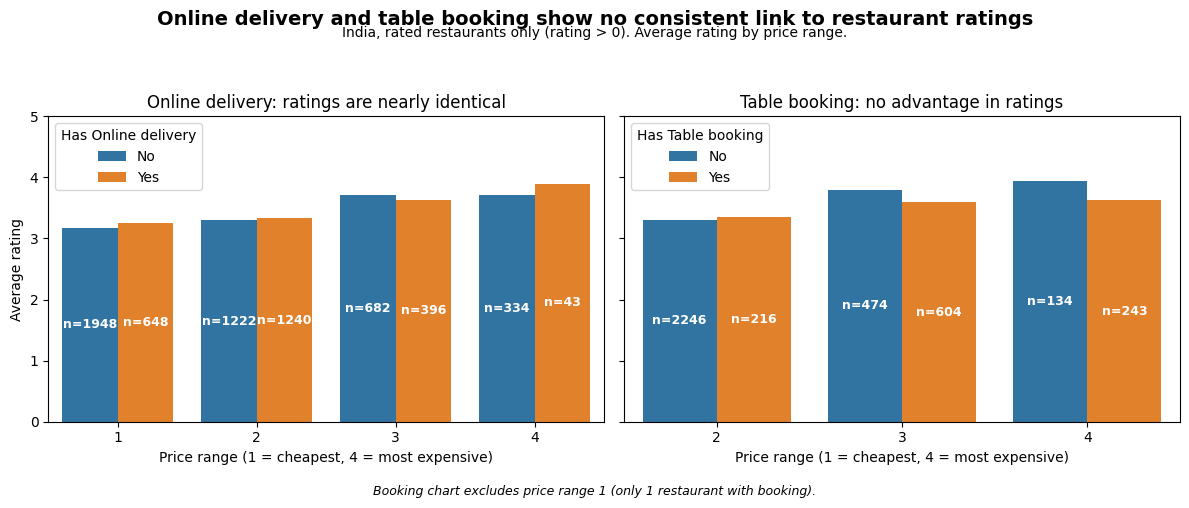

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.barplot(data=india_rated, x='Price range', y='Aggregate rating',
            hue='Has Online delivery', order=[1, 2, 3, 4], hue_order=HUE_ORDER,
            errorbar=None, ax=axes[0])
sns.barplot(data=data_tb, x='Price range', y='Aggregate rating',
            hue='Has Table booking', order=[2, 3, 4], hue_order=HUE_ORDER,
            errorbar=None, ax=axes[1])

add_counts(axes[0], india_rated, 'Has Online delivery', [1, 2, 3, 4])
add_counts(axes[1], data_tb, 'Has Table booking', [2, 3, 4])

axes[0].set_ylim(0, 5)
axes[0].set_title("Online delivery: ratings are nearly identical")
axes[1].set_title("Table booking: no advantage in ratings")

for ax in axes:
    ax.set_xlabel("Price range (1 = cheapest, 4 = most expensive)")
axes[0].set_ylabel("Average rating")
axes[1].set_ylabel("")

fig.suptitle("Online delivery and table booking show no consistent link to restaurant ratings",
             fontsize=14, fontweight='bold')
fig.text(0.5, 0.925, "India, rated restaurants only (rating > 0). Average rating by price range.",
         ha='center', fontsize=10)
fig.text(0.5, 0.01, "Booking chart excludes price range 1 (only 1 restaurant with booking).",
         ha='center', fontsize=9, style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 0.91])
plt.show()

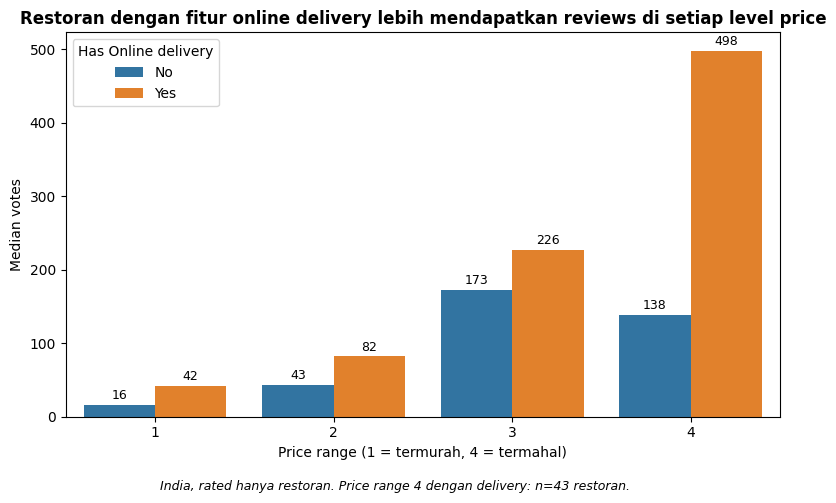

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=india_rated, x='Price range', y='Votes',
            hue='Has Online delivery', order=[1, 2, 3, 4], hue_order=HUE_ORDER,
            estimator='median', errorbar=None, ax=ax)

for c in ax.containers:
    ax.bar_label(c, fmt='%.0f', padding=2, fontsize=9)  # nilai median; hapus 2 baris ini jika tidak perlu

ax.set_title("Restoran dengan fitur online delivery lebih mendapatkan reviews di setiap level price",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Price range (1 = termurah, 4 = termahal)")
ax.set_ylabel("Median votes")

fig.text(0.5, 0.01, "India, rated hanya restoran. Price range 4 dengan delivery: n=43 restoran.",
         ha='center', fontsize=9, style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

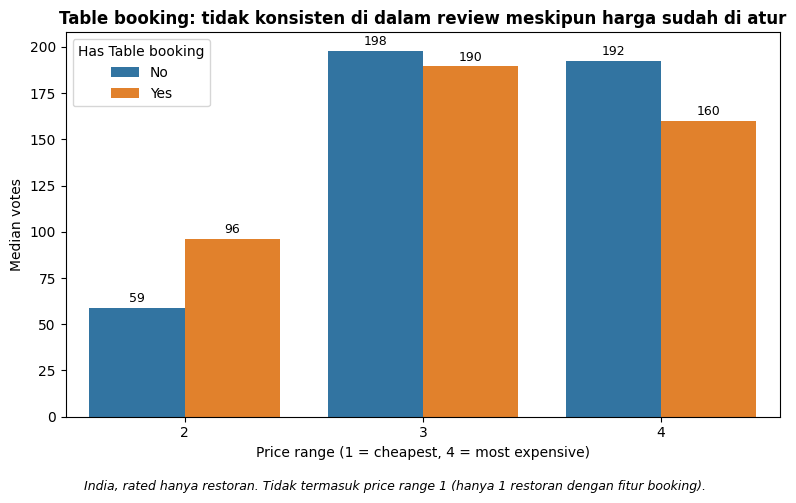

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=data_tb, x='Price range', y='Votes',
            hue='Has Table booking', order=[2, 3, 4], hue_order=HUE_ORDER,
            estimator='median', errorbar=None, ax=ax)

for c in ax.containers:
    ax.bar_label(c, fmt='%.0f', padding=2, fontsize=9)

ax.set_title("Table booking: tidak konsisten di dalam review meskipun harga sudah di atur",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Price range (1 = cheapest, 4 = most expensive)")
ax.set_ylabel("Median votes")

fig.text(0.5, 0.01, "India, rated hanya restoran. Tidak termasuk price range 1 (hanya 1 restoran dengan fitur booking).",
         ha='center', fontsize=9, style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## Kesimpulan

**Temuan**
- Setelah menghapus restoran yang tidak diberi peringkat (peringkat 0) dan mengontrol rentang harga, baik layanan pesan antar online maupun pemesanan meja tidak menunjukkan hubungan yang konsisten dengan peringkat yang lebih tinggi di antara 6.513 restoran yang diberi peringkat di India.
- Perbandingan mentah melebih-lebihkan efeknya: restoran yang tidak diberi peringkat dan konsentrasi restoran yang menerima pemesanan di rentang harga yang lebih tinggi memperbesar perbedaan tersebut.
- Rentang harga adalah faktor yang paling erat kaitannya dengan peringkat.
- Layanan pesan antar online memiliki lebih banyak ulasan (nilai median yang lebih tinggi) di setiap tingkat harga; pemesanan meja tidak demikian setelah harga dikontrol.

**Rekomendasi**
Menambahkan layanan pesan antar atau pemesanan meja kemungkinan tidak akan meningkatkan peringkat dengan sendirinya. Layanan pesan antar dapat membantu visibilitas melalui lebih banyak ulasan, tetapi ini adalah asosiasi, bukan bukti sebab dan akibat.

**Keterbatasan** 
Data observasional; kota tidak dikontrol; tidak ada uji signifikansi; kelompok kecil dikecualikan atau ditandai (pemesanan pada rentang harga 1, n=1; layanan pesan antar pada rentang harga 4, n=43); hanya India.